# Round 2 — EDA

Brief exploratory analysis of the Round 2 data capsule. Mirrors the structure used for Round 1 / the Tutorial round: load, sanity-check, summarise per product per day, then inspect the price process, order book, and trades.

**Products (same as Round 1):**
- `ASH_COATED_OSMIUM` — stationary, anchored around 10,000
- `INTARIAN_PEPPER_ROOT` — upward-drifting

**Spoiler from comparing to Round 1:** the underlying process is unchanged. Round 2 is effectively three more sample days from the same distribution, not a new regime. This notebook confirms that and quantifies the drift and mean-reversion parameters.

## 1. Setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:.3f}")

DAYS = [-1, 0, 1]

OSMIUM = "ASH_COATED_OSMIUM"
PEPPER = "INTARIAN_PEPPER_ROOT"


## 2. Load

Three day-files, concatenated. We add a `global_t` column that chains the days end-to-end — that's the natural frame for pepper, since each day starts where the previous one left off.

In [25]:
price_frames = []
trade_frames = []

for d in DAYS:
    p = pd.read_csv(f"../data/round2-data/prices_round_2_day_{d}.csv", sep=";")
    t = pd.read_csv(f"../data/round2-data/trades_round_2_day_{d}.csv", sep = ";")
    price_frames.append(p)
    trade_frames.append(t.assign(day=d))  # trades file has no day column

prices = pd.concat(price_frames, ignore_index=True)
trades = pd.concat(trade_frames, ignore_index=True)

# Chain days into one continuous global time axis
DAY_OFFSET = {-1: 0, 0: 1_000_000, 1: 2_000_000}
prices["global_t"] = prices["day"].map(DAY_OFFSET) + prices["timestamp"]
trades["global_t"] = trades["day"].map(DAY_OFFSET) + trades["timestamp"]

print(f"prices: {len(prices):,} rows  |  days={sorted(prices['day'].unique())}")
print(f"trades: {len(trades):,} rows")
prices.head()

prices: 60,000 rows  |  days=[np.int64(-1), np.int64(0), np.int64(1)]
trades: 2,391 rows


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_t
0,-1,0,INTARIAN_PEPPER_ROOT,10994.000,9.000,NaN,NaN,NaN,NaN,11009.000,25.000,NaN,NaN,NaN,NaN,11001.500,0.000,0
1,-1,0,ASH_COATED_OSMIUM,9982.000,21.000,NaN,NaN,NaN,NaN,10000.000,13.000,10003.000,21.000,NaN,NaN,9991.000,0.000,0
2,-1,100,ASH_COATED_OSMIUM,9984.000,15.000,NaN,NaN,NaN,NaN,10000.000,15.000,10003.000,26.000,NaN,NaN,9992.000,0.000,100
3,-1,100,INTARIAN_PEPPER_ROOT,10994.000,8.000,10991.000,22.000,NaN,NaN,11006.000,8.000,11009.000,22.000,NaN,NaN,11000.000,0.000,100
4,-1,200,ASH_COATED_OSMIUM,9985.000,15.000,9982.000,30.000,NaN,NaN,10001.000,15.000,NaN,NaN,NaN,NaN,9993.000,0.000,200


## 3. Data quality

Check for holes before the analysis gets ahead of itself. Prosperity books occasionally go one-sided or report a zero mid — any downstream fair-value calc needs to handle that.

In [13]:
print(f"total rows              : {len(prices):,}")
print(f"zero mid_price rows     : {(prices['mid_price'] == 0).sum()}")
print(f"NaN mid_price rows      : {prices['mid_price'].isna().sum()}")

one_sided = prices['bid_price_1'].isna() | prices['ask_price_1'].isna()
print(f"one-sided book snapshots: {one_sided.sum()}  ({one_sided.mean()*100:.1f}%)")

# Book depth usage (how often are levels 2 and 3 populated?)
depth_cols = ['bid_price_2', 'bid_price_3', 'ask_price_2', 'ask_price_3']
depth_usage = prices[depth_cols].notna().mean() * 100
print("\nbook-depth population rate (%):")
print(depth_usage.round(1))

total rows              : 60,000
zero mid_price rows     : 100
NaN mid_price rows      : 0
one-sided book snapshots: 4568  (7.6%)

book-depth population rate (%):
bid_price_2   64.800
bid_price_3    1.900
ask_price_2   64.900
ask_price_3    2.000
dtype: float64


## 4. Per-day, per-product summary

Quick numerical pass before plotting anything.

In [14]:
rows = []
for prod in sorted(prices['product'].unique()):
    for d in DAYS:
        sub = prices[(prices['product'] == prod) & (prices['day'] == d)]
        mid = sub['mid_price'].replace(0, np.nan).dropna()
        spread = (sub['ask_price_1'] - sub['bid_price_1']).dropna()
        rows.append({
            'product': prod,
            'day': d,
            'n': len(mid),
            'mid_mean': mid.mean(),
            'mid_std': mid.std(),
            'mid_min': mid.min(),
            'mid_max': mid.max(),
            'spread_median': spread.median(),
        })
pd.DataFrame(rows)

,product,day,n,mid_mean,mid_std,mid_min,mid_max,spread_median
0,ASH_COATED_OSMIUM,-1,9985,10000.825,4.467,9981.000,10020.000,16.000
1,ASH_COATED_OSMIUM,0,9984,10001.607,5.660,9979.000,10023.000,16.000
2,ASH_COATED_OSMIUM,1,9978,10000.205,5.019,9980.000,10019.000,16.000
3,INTARIAN_PEPPER_ROOT,-1,9987,11500.124,288.653,10998.000,12001.500,13.000
4,INTARIAN_PEPPER_ROOT,0,9982,12499.866,288.610,11996.000,13008.000,14.000
5,INTARIAN_PEPPER_ROOT,1,9984,13500.057,288.746,12995.000,14003.000,15.000


Two things to read off this table:

- **Osmium** has nearly identical mean/std/range across all three days — the anchor hasn't moved.
- **Pepper** means step up by almost exactly 1,000 each day (11,500 → 12,500 → 13,500), while the std stays pinned at ~289. That's consistent with a pure additive drift: the location changes, the shape doesn't.

## 5. Osmium — the stationary leg

Plot the mid over all three days, then check how tightly it's anchored and how persistent the deviations are (i.e. mean-reversion strength).

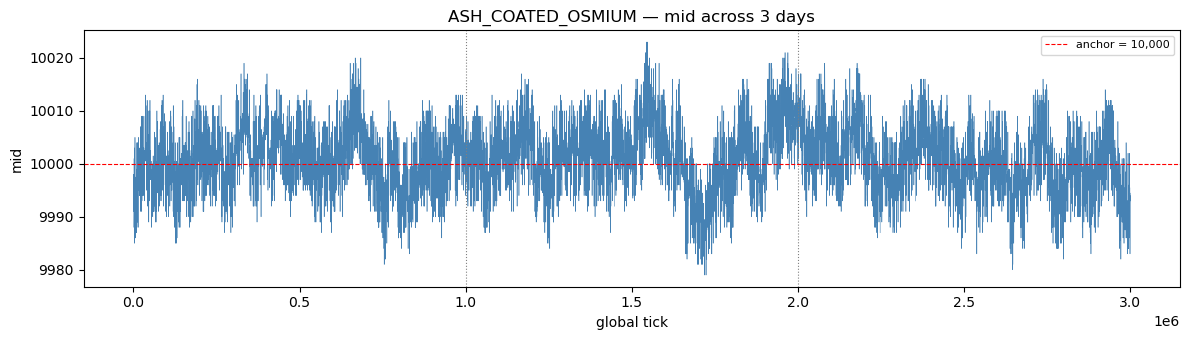

In [15]:
osm = prices[prices['product'] == OSMIUM].sort_values('global_t')
mid_o = osm['mid_price'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(osm['global_t'], mid_o, linewidth=0.4, color='steelblue')
ax.axhline(10000, color='red', linestyle='--', linewidth=0.8, label='anchor = 10,000')
for b in (1_000_000, 2_000_000):
    ax.axvline(b, color='gray', linestyle=':', linewidth=0.8)
ax.set_title(f"{OSMIUM} — mid across 3 days")
ax.set_xlabel("global tick"); ax.set_ylabel("mid")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [16]:
# Anchor coverage
mid = mid_o.dropna().values
for w in (5, 10, 15, 20):
    pct = ((mid >= 10000 - w) & (mid <= 10000 + w)).mean() * 100
    print(f"  within ±{w:>2} of 10,000: {pct:5.1f}%")

# Autocorrelation structure of the deviation from mean
centered = mid - mid.mean()
print("\nautocorrelation of deviation from mean:")
for lag in (1, 5, 10, 50, 100, 200, 500):
    if len(centered) > lag:
        rho = np.corrcoef(centered[lag:], centered[:-lag])[0, 1]
        print(f"  AR({lag:>3}): {rho:+.3f}")

  within ± 5 of 10,000:  72.4%
  within ±10 of 10,000:  94.9%
  within ±15 of 10,000:  99.4%
  within ±20 of 10,000: 100.0%

autocorrelation of deviation from mean:
  AR(  1): +0.739
  AR(  5): +0.729
  AR( 10): +0.721
  AR( 50): +0.652
  AR(100): +0.571
  AR(200): +0.410
  AR(500): +0.131


**Interpretation:** strong AR(1) (~0.74) with slow decay means osmium mean-reverts but not instantly. A market-maker posting around 10,000 earns the ~16-wide spread; inventory should be managed on the assumption that deviations *will* come back, but might take a few hundred ticks to do so. Don't size up purely because it looks overbought at tick t.

### 5a. Osmium distribution and spread

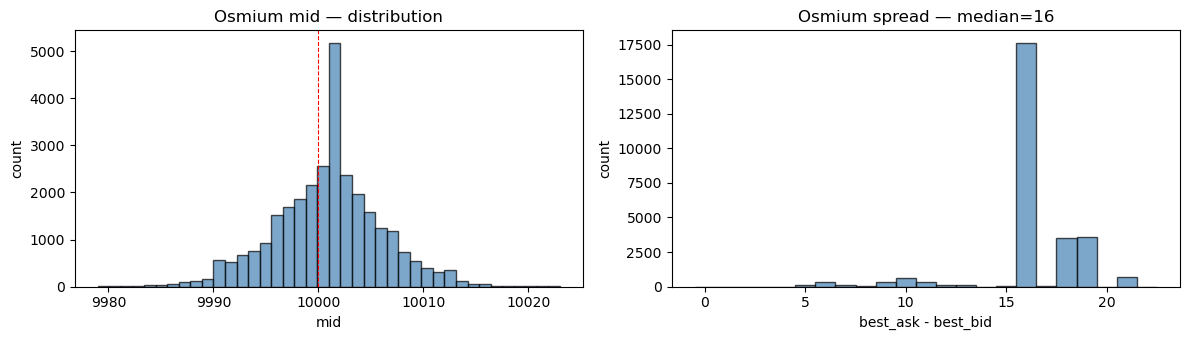

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].hist(mid_o.dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(10000, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title("Osmium mid — distribution")
axes[0].set_xlabel("mid"); axes[0].set_ylabel("count")

spread_o = (osm['ask_price_1'] - osm['bid_price_1']).dropna()
axes[1].hist(spread_o, bins=range(0, int(spread_o.max()) + 2), color='steelblue',
             edgecolor='black', alpha=0.7, align='left')
axes[1].set_title(f"Osmium spread — median={spread_o.median():.0f}")
axes[1].set_xlabel("best_ask - best_bid"); axes[1].set_ylabel("count")

plt.tight_layout(); plt.show()

## 6. Pepper — the drifting leg

Fit a linear trend on the stitched 3-day series and look at the residual. The important question isn't *what's the slope* (you can eyeball that), it's *is there any tradeable structure left after you remove the drift*.

In [18]:
pep = prices[prices['product'] == PEPPER].sort_values('global_t')
mid_p = pep['mid_price'].replace(0, np.nan)
mid_p_clean = mid_p.dropna()

t = np.arange(len(mid_p_clean))
slope, intercept = np.polyfit(t, mid_p_clean.values, 1)
resid = mid_p_clean.values - (slope * t + intercept)

print(f"linear fit on stitched series:")
print(f"  slope     = {slope:.5f} per tick")
print(f"  intercept = {intercept:.2f}")
print(f"  ≈ {slope * 10000:.1f} per day (10k ticks/day)")
print(f"\nresidual: std={resid.std():.3f}  "
      f"skew={pd.Series(resid).skew():.3f}  "
      f"kurtosis={pd.Series(resid).kurtosis():.3f}")

print("\nautocorrelation of residual:")
for lag in (1, 5, 10, 50, 100):
    rho = np.corrcoef(resid[lag:], resid[:-lag])[0, 1]
    print(f"  AR({lag:>3}): {rho:+.4f}")

linear fit on stitched series:
  slope     = 0.10016 per tick
  intercept = 10999.95
  ≈ 1001.6 per day (10k ticks/day)

residual: std=2.380  skew=-0.113  kurtosis=5.774

autocorrelation of residual:
  AR(  1): +0.0154
  AR(  5): -0.0031
  AR( 10): +0.0103
  AR( 50): +0.0023
  AR(100): +0.0126


**Key result:** residual AR(1) is essentially zero (~0.015). That means once you remove the linear drift, what's left is white noise — there's *no mean-reversion edge on the noise around the trend*. Any alpha in pepper comes from riding the drift itself, not from fading deviations from it.

That's a meaningful contrast with osmium, where the noise *is* the signal.

### 6a. Pepper: mid + trend, and detrended residual

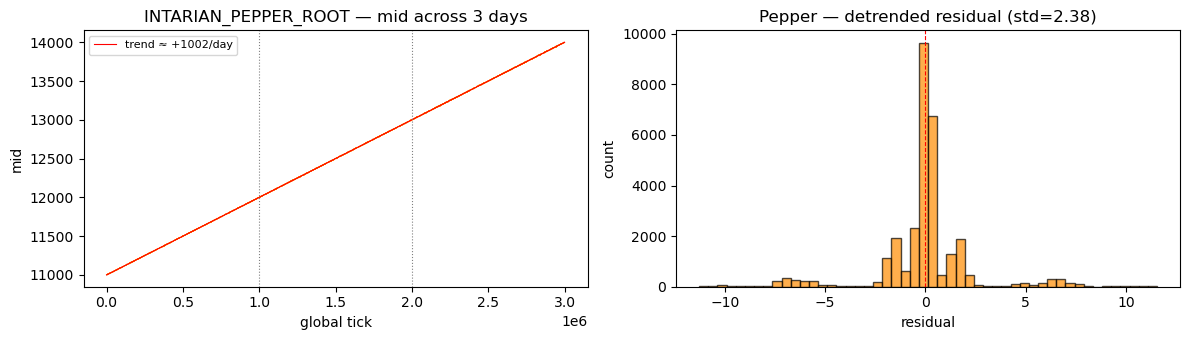

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].plot(pep['global_t'], mid_p, linewidth=0.4, color='darkorange')
trend_x = pep.loc[mid_p.notna(), 'global_t'].values
axes[0].plot(trend_x, slope * t + intercept, color='red', linewidth=0.8,
             label=f"trend ≈ +{slope*10000:.0f}/day")
for b in (1_000_000, 2_000_000):
    axes[0].axvline(b, color='gray', linestyle=':', linewidth=0.8)
axes[0].set_title(f"{PEPPER} — mid across 3 days")
axes[0].set_xlabel("global tick"); axes[0].set_ylabel("mid")
axes[0].legend(fontsize=8)

axes[1].hist(resid, bins=50, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=0.8)
axes[1].set_title(f"Pepper — detrended residual (std={resid.std():.2f})")
axes[1].set_xlabel("residual"); axes[1].set_ylabel("count")

plt.tight_layout(); plt.show()

The residual histogram has a sharp central spike plus smaller side-bumps around ±6 to ±10. That's not a clean Gaussian — suggests the book occasionally steps in discrete amounts (tick-size artefacts or wider-spread snapshots). Worth knowing if you ever want to model pepper residuals parametrically.

## 7. Trades

Trade-arrival and size distribution. Counterparty columns are fully NaN in Prosperity 4 (as in Round 1) — no informed-trader signal to extract from trade identity this round.

In [26]:
print(f"trades: {len(trades):,} rows across 3 days")
print(f"buyer nunique  : {trades['buyer'].nunique(dropna=False)}")
print(f"seller nunique : {trades['seller'].nunique(dropna=False)}")
print(f"buyer NaN count : {trades['buyer'].isna().sum()}  ({trades['buyer'].isna().mean()*100:.0f}%)")
print(f"seller NaN count: {trades['seller'].isna().sum()}  ({trades['seller'].isna().mean()*100:.0f}%)")

print("\ntrade count by symbol × day:")
print(trades.groupby(['symbol', 'day']).size().unstack())

print("\naverage trade size by symbol:")
print(trades.groupby('symbol')['quantity'].agg(['mean', 'median', 'max']))

trades: 2,391 rows across 3 days
buyer nunique  : 1
seller nunique : 1
buyer NaN count : 2391  (100%)
seller NaN count: 2391  (100%)

trade count by symbol × day:
day                    -1    0    1
symbol                             
ASH_COATED_OSMIUM     459  471  465
INTARIAN_PEPPER_ROOT  331  332  333

average trade size by symbol:
                      mean  median  max
symbol                                 
ASH_COATED_OSMIUM    5.109   5.000   10
INTARIAN_PEPPER_ROOT 5.053   5.000    8


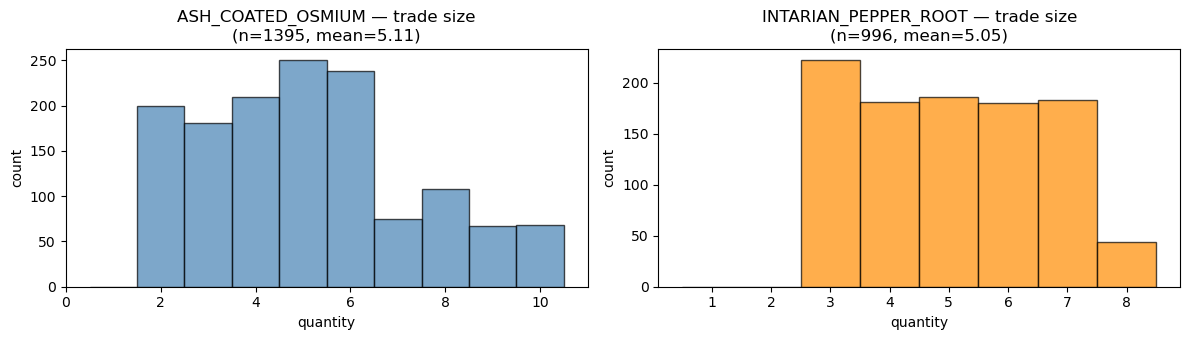

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for i, sym in enumerate([OSMIUM, PEPPER]):
    sizes = trades.loc[trades['symbol'] == sym, 'quantity']
    axes[i].hist(sizes, bins=range(1, int(sizes.max()) + 2),
                 color='steelblue' if sym == OSMIUM else 'darkorange',
                 edgecolor='black', alpha=0.7, align='left')
    axes[i].set_title(f"{sym} — trade size\n(n={len(sizes)}, mean={sizes.mean():.2f})")
    axes[i].set_xlabel("quantity"); axes[i].set_ylabel("count")

plt.tight_layout(); plt.show()

## 8. Takeaways

**Versus Round 1:** same two products, same schema, same stochastic process. Round 2's contribution is three additional sample days — useful for walk-forward validation, not a new regime.

**Osmium (stationary):**
- Anchor at 10,000, std ~5, spread ~16.
- ~95% of snapshots land within ±10 of the anchor, 99.4% within ±15.
- Strong, slow mean-reversion: AR(1) ≈ 0.74, still positive at lag 200.
- **Trade idea:** post quotes around 10,000, earn the spread, manage inventory with the understanding that reversion is statistical rather than instant.

**Pepper (drifting):**
- Drift ≈ +1,000 per day (slope ≈ 0.1/tick) on the stitched 3-day series.
- Residual std ~2.4 with AR(1) ≈ 0 — noise around the trend is not serially correlated.
- **Trade idea:** ride the drift. Mean-reversion strategies on pepper's detrended residual will earn nothing because there's no autocorrelation to exploit.

**Validation plan:** fit on day −1, test on day 0, verify on day 1 (or any permutation). Days are i.i.d. draws from the same process, so consistency across days is a strong robustness check.